In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'historical_data.csv'

In [4]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\hayya\Downloads\bitcoin market sentiment analysis
['.ipynb_checkpoints', 'data', 'image', 'notebook.ipynb', 'notebooks.ipynb', 'README.md', 'requirements.txt', 'venv']


In [8]:
trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

In [9]:
print("Hello")

Hello


In [10]:
import os
print(os.listdir("data"))

['fear_greed_index.csv', 'historical_data.csv']


In [11]:
trades = pd.read_csv("data/historical_data.csv")
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [12]:
sentiment = pd.read_csv("data/fear_greed_index.csv")
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [13]:
print("Trader Dataset Shape:", trades.shape)
print("Fear & Greed Dataset Shape:", sentiment.shape)

trades.info()

Trader Dataset Shape: (211224, 16)
Fear & Greed Dataset Shape: (2644, 4)
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timest

In [14]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [16]:
print("Missing values in Trader Dataset")
print(trades.isnull().sum())

print("\nMissing values in Sentiment Dataset")
print(sentiment.isnull().sum())

Missing values in Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [17]:
print("Trader Dataset Duplicates:", trades.duplicated().sum())
print("Sentiment Dataset Duplicates:", sentiment.duplicated().sum())

Trader Dataset Duplicates: 0
Sentiment Dataset Duplicates: 0


In [18]:

trades["Date"] = pd.to_datetime(trades["Timestamp IST"]).dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [19]:
trades["Timestamp IST"].head()

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: str

In [20]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
).dt.date

In [21]:
trades["Date"].head()

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object

In [22]:
sentiment["Date"] = pd.to_datetime(sentiment["date"]).dt.date

In [23]:
df = trades.merge(
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [24]:
print(df.shape)

(211224, 19)


In [25]:
df["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [26]:
df.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [27]:
df.groupby("classification")["leverage"].mean()

KeyError: 'Column not found: leverage'

In [28]:
print(df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'value'],
      dtype='str')


In [29]:
df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [30]:
df["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [31]:
df.groupby("classification")["Size USD"].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [32]:
pd.crosstab(df["classification"], df["Side"])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [33]:
df["Profit"] = df["Closed PnL"] > 0

pd.crosstab(df["classification"], df["Profit"])

Profit,False,True
classification,,
Extreme Fear,13469,7931
Extreme Greed,21398,18594
Fear,35818,26019
Greed,30945,19358
Neutral,22725,14961


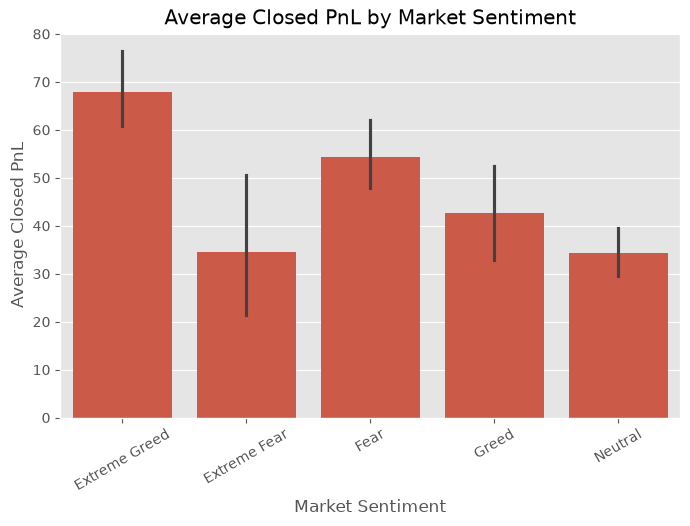

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=30)

plt.show()

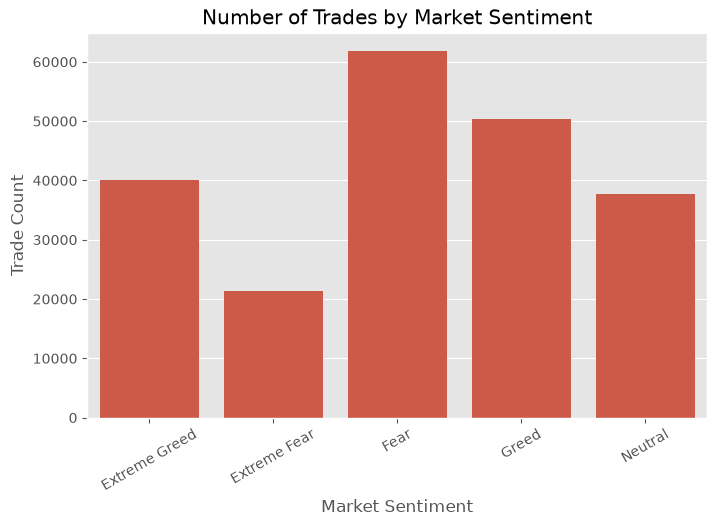

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="classification")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=30)

plt.show()

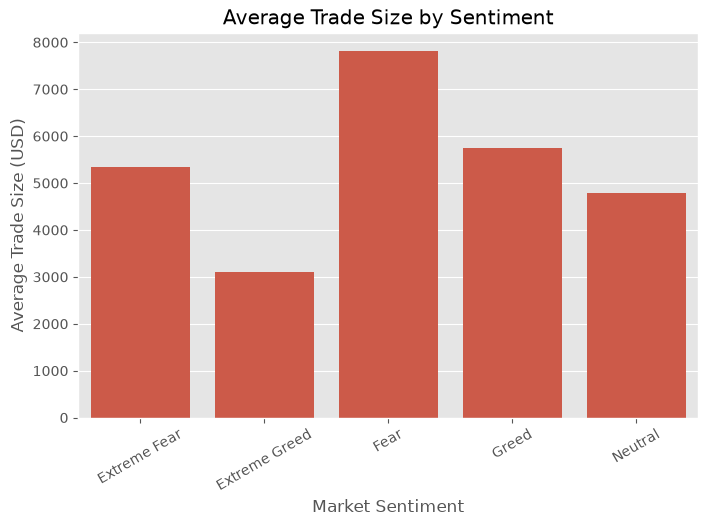

In [36]:
avg_size = df.groupby("classification")["Size USD"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=avg_size,
            x="classification",
            y="Size USD")

plt.title("Average Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)

plt.show()

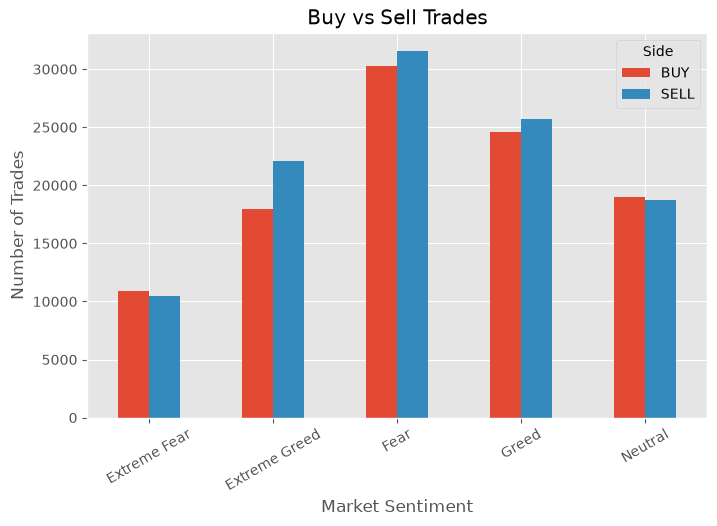

In [37]:
pd.crosstab(df["classification"], df["Side"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Buy vs Sell Trades")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=30)

plt.show()

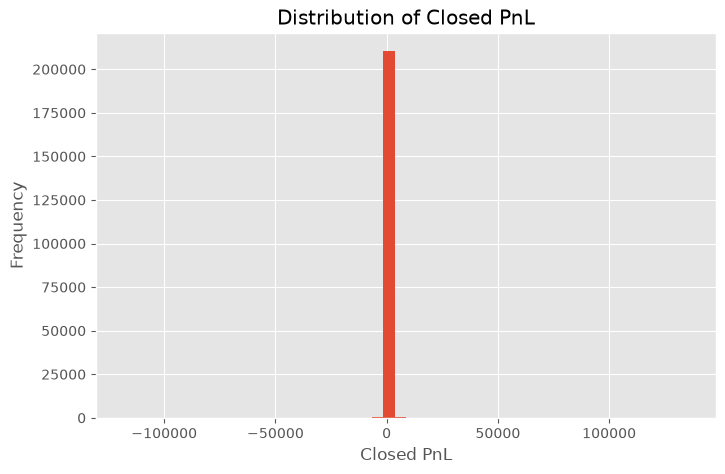

In [38]:
plt.figure(figsize=(8,5))

plt.hist(df["Closed PnL"], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

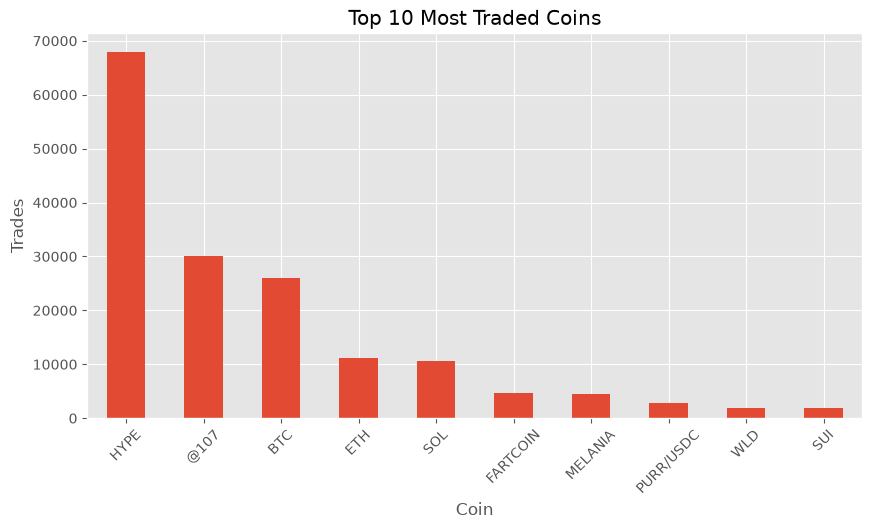

In [39]:
topcoins = df["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

topcoins.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Trades")

plt.xticks(rotation=45)

plt.show()

# Key Insights

1. The highest average Closed PnL was observed during Extreme Greed, indicating that traders generally realized higher profits during periods of strong market optimism.

2. Fear periods also showed relatively good profitability, suggesting that experienced traders were able to capitalize on market volatility.

3. Neutral and Extreme Fear periods recorded comparatively lower average Closed PnL.

4. The trading activity was concentrated on a few major coins. HYPE had the highest number of trades, followed by @107 and BTC.

5. Trade size and trading activity varied across different market sentiment categories, indicating that market sentiment influenced trading behaviour.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and historical trader performance by combining the Fear & Greed Index with Hyperliquid trading data. The analysis showed that market sentiment has a noticeable impact on trading outcomes. Traders achieved higher average realized profits during Greed and Extreme Greed periods, while Neutral and Extreme Fear periods generally resulted in lower profitability. These findings suggest that market sentiment can be used as an additional indicator to support trading decisions and improve risk management strategies.